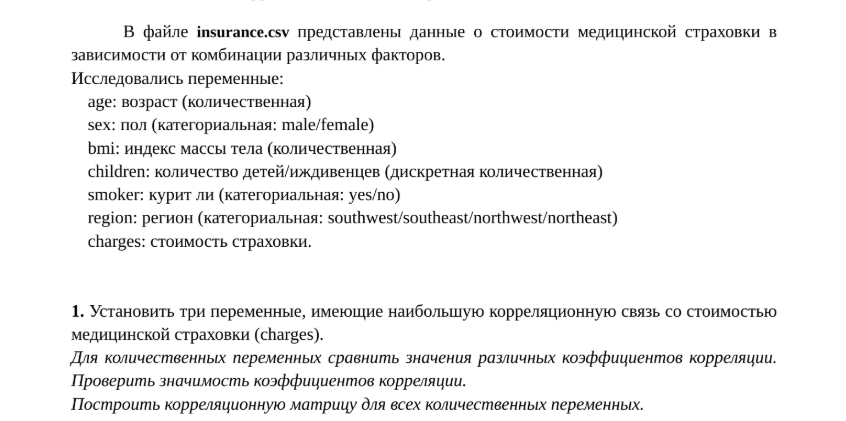

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = pd.read_csv("insurance.csv")

--- Correlation Coefficients Comparison & Significance ---


,Variable,Pearson_R,P_Pearson,Pearson_Sig,Spearman_R,Spearman_Sig,Kendall_R,Kendall_Sig
0,age,0.299008,4.886693e-29,Yes,0.534392,Yes,0.475302,Yes
1,bmi,0.198341,2.459086e-13,Yes,0.119396,Yes,0.082524,Yes
2,children,0.067998,1.285213e-02,Yes,0.133339,Yes,0.103107,Yes



--- Top 3 variables correlated with charges ---


smoker_enc    0.787251
age           0.299008
bmi           0.198341
Name: charges, dtype: float64

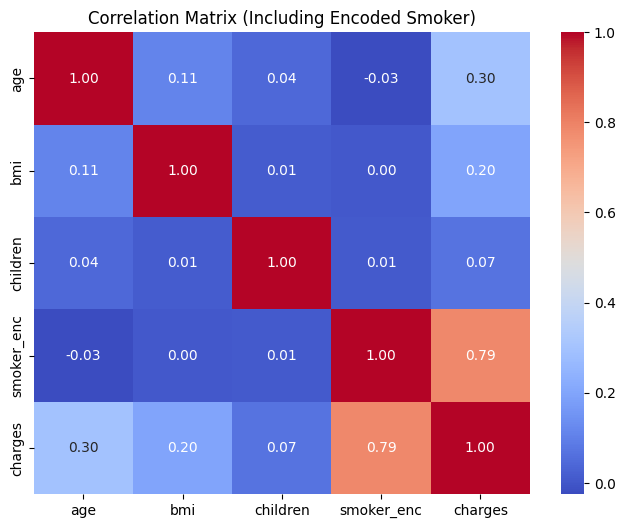

In [24]:
# 1.1 Variables setup
num_vars = ["age", "bmi", "children"]
target = "charges"
alpha = 0.05  # Significance level
n = len(df)

corr_results = []

# 1.2 Calculation loop
for var in num_vars:
    # Pearson (Linear)
    r, p_p = stats.pearsonr(df[var], df[target])

    # Manual T-statistic calculation (from your image)
    # t = (r * sqrt(n-2)) / sqrt(1 - r^2)
    # t_stat = (r * np.sqrt(n - 2)) / np.sqrt(1 - r**2)

    # Spearman (Rank)
    s_r, s_p = stats.spearmanr(df[var], df[target])

    # Kendall (Robust)
    k_r, k_p = stats.kendalltau(df[var], df[target])

    corr_results.append(
        {
            "Variable": var,
            "Pearson_R": r,
            # "T_Stat": t_stat,
            "P_Pearson": p_p,
            "Pearson_Sig": "Yes" if p_p < alpha else "No",
            "Spearman_R": s_r,
            "Spearman_Sig": "Yes" if s_p < alpha else "No",
            "Kendall_R": k_r,
            "Kendall_Sig": "Yes" if k_p < alpha else "No",
        }
    )

# Convert to DataFrame
corr_df = pd.DataFrame(corr_results)

print("--- Correlation Coefficients Comparison & Significance ---")
display(corr_df)

# 1.3 Find top 3 (including encoded smoker as it's the strongest factor)
# Let's quickly encode smoker to check its correlation
df_temp = df.copy()
df_temp["smoker_enc"] = df_temp["smoker"].map({"yes": 1, "no": 0})
full_corr = (
    df_temp[num_vars + ["smoker_enc", "charges"]]
    .corr()["charges"]
    .sort_values(ascending=False)
)

print("\n--- Top 3 variables correlated with charges ---")
display(full_corr[1:4])  # Skipping 'charges' itself

# 1.4 Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_temp[num_vars + ["smoker_enc", "charges"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Matrix (Including Encoded Smoker)")
plt.show()

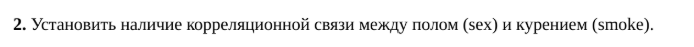

In [11]:
# 2.1 Create a contingency table
contingency_table = pd.crosstab(df["sex"], df["smoker"])
print("\n--- Contingency Table: Sex vs Smoker ---")
print(contingency_table)

# 2.2 Perform Chi-Square Test
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_table)


# 2.3 Calculate Cramer's V (strength of association)
def get_cramers_v(table):
    chi2_val = stats.chi2_contingency(table)[0]
    n = table.sum().sum()
    phi2 = chi2_val / n
    r, k = table.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))


v_kramer = get_cramers_v(contingency_table)

print(f"\n--- Chi-Square Test Results ---")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_chi:.4f}")
print(f"Cramer's V: {v_kramer:.4f}")
print(f"Significant relationship: {p_chi < 0.05}")


--- Contingency Table: Sex vs Smoker ---
smoker   no  yes
sex             
female  547  115
male    517  159

--- Chi-Square Test Results ---
Chi-square statistic: 7.3929
P-value: 0.0065
Cramer's V: 0.0743
Significant relationship: True


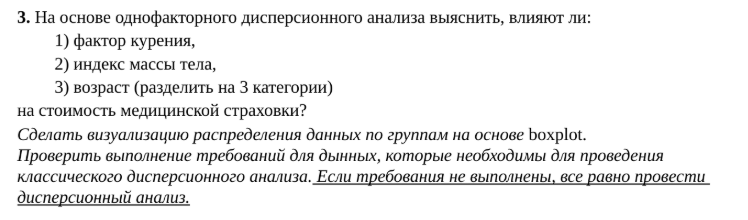


--- Analysis for Factor: smoker ---
Normality p-value: 0.0000
Variance Homogeneity p-value: 0.0000
ANOVA F-stat: 2177.6149, p-value: 8.2714e-283

--- Analysis for Factor: bmi_cat ---
Normality p-value: 0.0000
Variance Homogeneity p-value: 0.0000
ANOVA F-stat: 28.0041, p-value: 1.2195e-12

--- Analysis for Factor: age_cat ---
Normality p-value: 0.0000
Variance Homogeneity p-value: 0.8485
ANOVA F-stat: 54.3570, p-value: 2.0187e-23


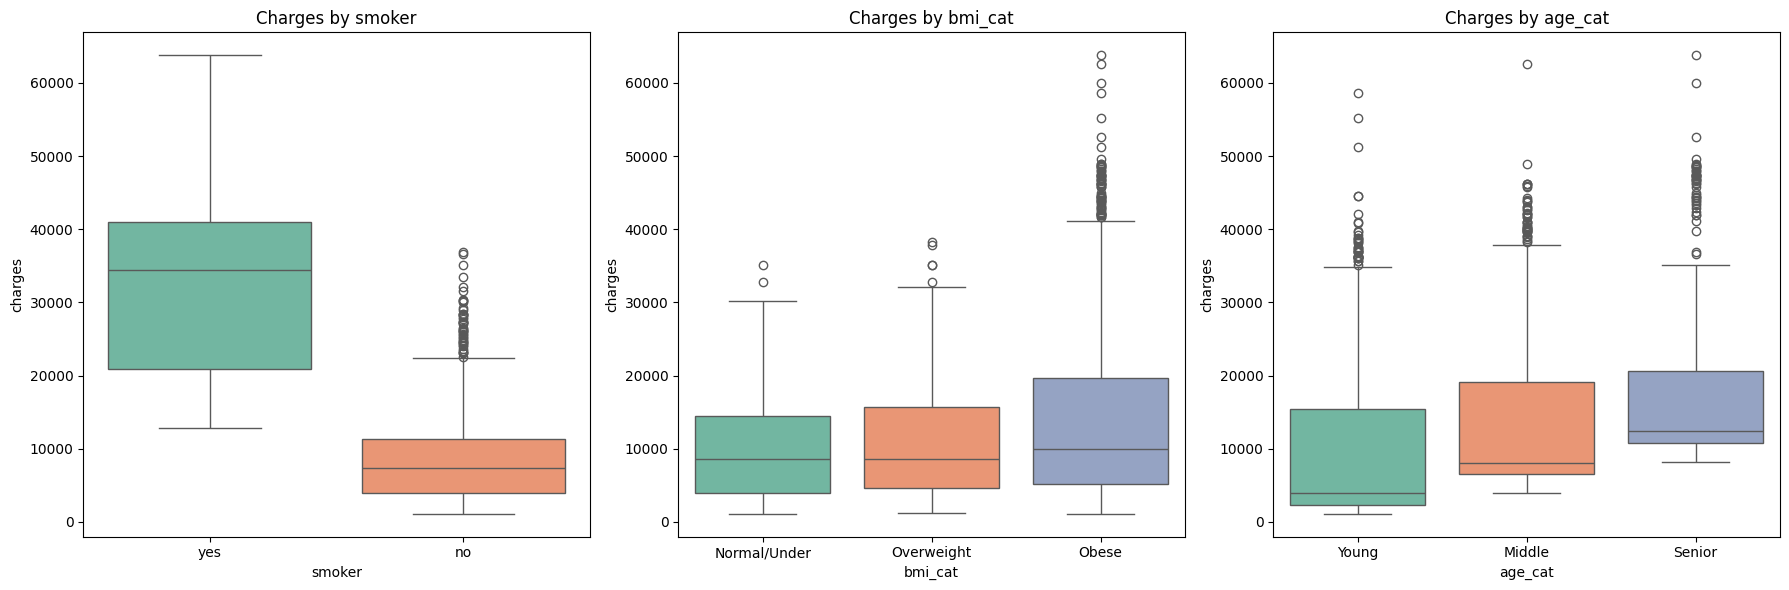

In [ ]:
# Assuming df is already loaded and categorized
# 3.1 Visualization and ANOVA with fixed warnings
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

factors = ["smoker", "bmi_cat", "age_cat"]
target = "charges"

for i, factor in enumerate(factors):
    # Fixed FutureWarning: assign x to hue and set legend=False
    sns.boxplot(
        x=factor,
        y=target,
        data=df,
        ax=axes[i],
        hue=factor,
        palette="Set2",
        legend=False,
    )
    axes[i].set_title(f"Charges by {factor}")

    # Fixed FutureWarning: set observed=True for categorical groupby
    groups = [group[target].values for name, group in df.groupby(factor, observed=True)]

    # Statistics (Shapiro, Levene, ANOVA)
    _, p_shapiro = stats.shapiro(df[target])
    _, p_levene = stats.levene(*groups)
    f_stat, p_anova = stats.f_oneway(*groups)

    print(f"\n--- Analysis for Factor: {factor} ---")
    print(f"Normality p-value: {p_shapiro:.4f}")
    print(f"Variance Homogeneity p-value: {p_levene:.4f}")
    print(f"ANOVA F-stat: {f_stat:.4f}, p-value: {p_anova:.4e}")
    if p_anova < 0.05:
        print(
            f"CONCLUSION: The factor '{factor}' has a STATISTICALLY SIGNIFICANT effect on insurance charges."
        )
    else:
        print(f"CONCLUSION: The factor '{factor}' does NOT have a significant effect.")

plt.tight_layout()
plt.show()

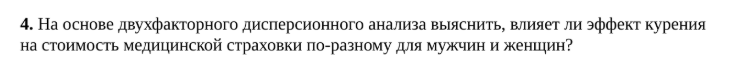

--- Two-Way ANOVA Table ---
                        sum_sq      df            F         PR(>F)
C(sex)            1.421312e+06     1.0     0.025601   8.729026e-01
C(smoker)         1.208777e+11     1.0  2177.284440  1.247285e-282
C(sex):C(smoker)  4.923397e+08     1.0     8.868165   2.954255e-03
Residual          7.406056e+10  1334.0          NaN            NaN


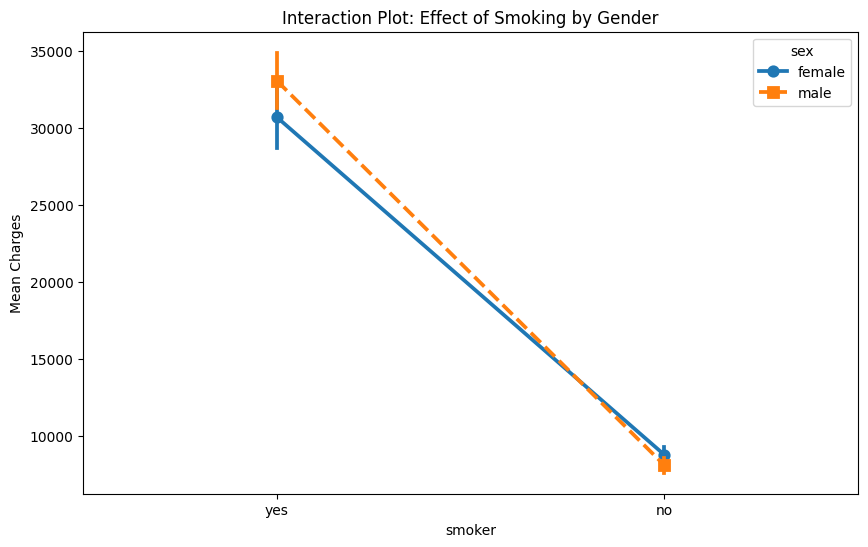

In [13]:
# 4.1 Define the model
# 'charges ~ C(sex) * C(smoker)' means we look at:
# 1. Main effect of sex
# 2. Main effect of smoker
# 3. Interaction effect (sex * smoker)
model = ols("charges ~ C(sex) * C(smoker)", data=df).fit()

# 4.2 Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print("--- Two-Way ANOVA Table ---")
print(anova_table)

# 4.3 Visualization: Interaction Plot
# This plot shows if the lines for male/female are parallel.
# If they cross or have different slopes, there is an interaction.
plt.figure(figsize=(10, 6))
sns.pointplot(
    x="smoker",
    y="charges",
    hue="sex",
    data=df,
    markers=["o", "s"],
    linestyles=["-", "--"],
)
plt.title("Interaction Plot: Effect of Smoking by Gender")
plt.ylabel("Mean Charges")
plt.show()